Number of samples: 1000
Sampling frequency: 1000 Hz
Input frequency: 5 Hz

========== DPCM RESULTS ==========
DPCM Quantization Step = 0.1
DPCM MSE = 0.0007703270090782388


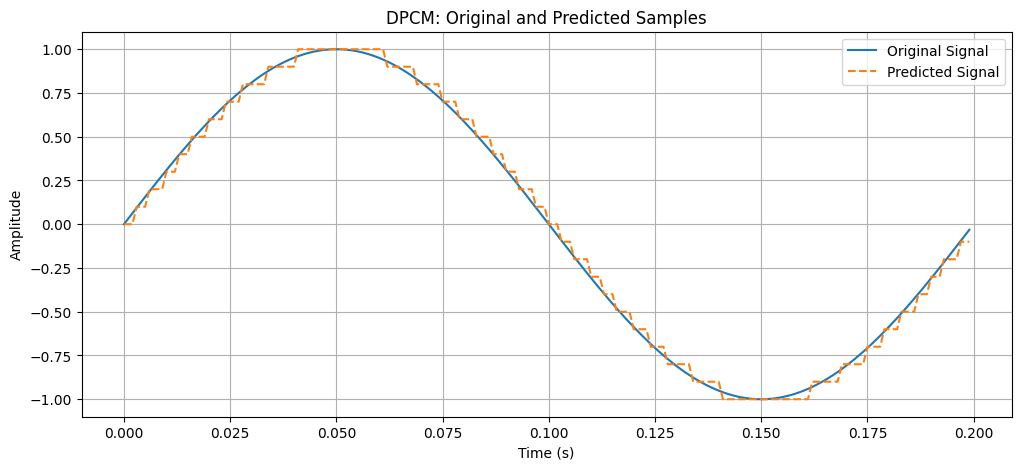

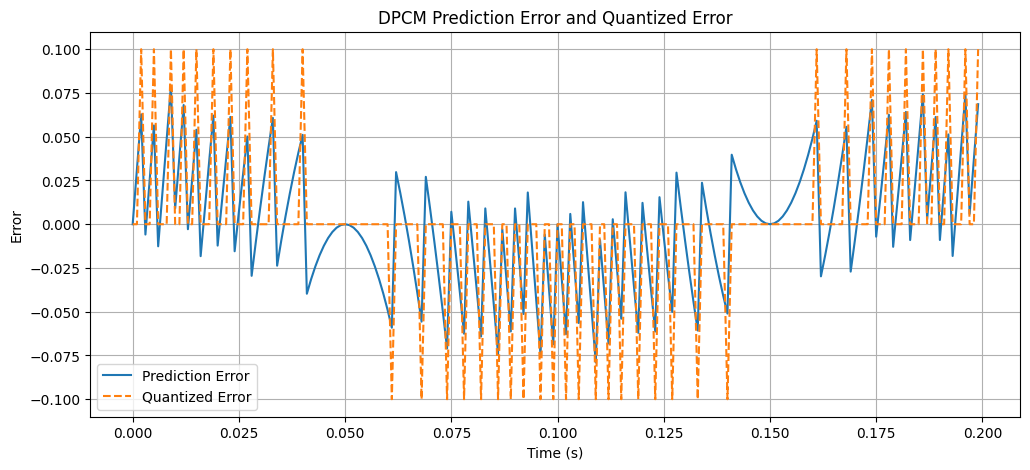

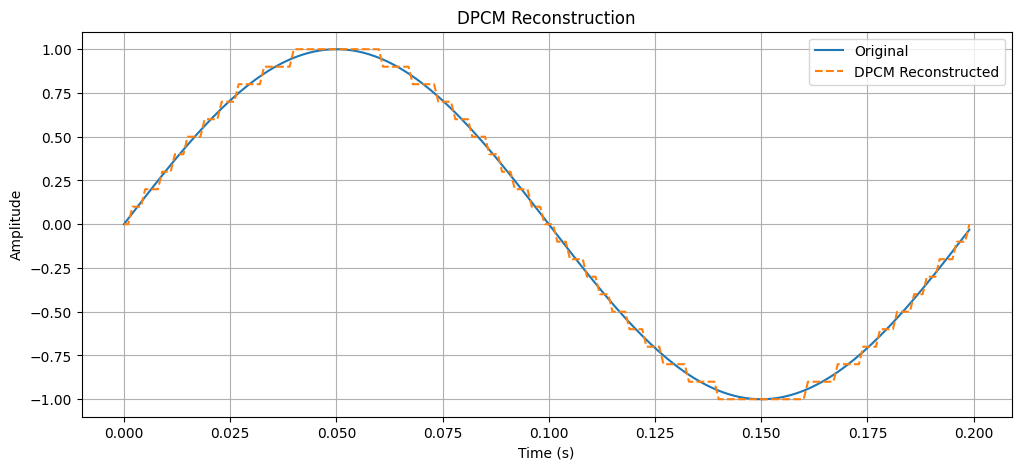


Delta = 0.02
MSE   = 0.0647252854596577

Delta = 0.08
MSE   = 0.0021541762945612745

Delta = 0.2
MSE   = 0.0138470937253928

========== MANDATORY VALIDATION ==========
Delta = 0.020 : Every output step is exactly +Delta or -Delta -> True
Delta = 0.080 : Every output step is exactly +Delta or -Delta -> True
Delta = 0.200 : Every output step is exactly +Delta or -Delta -> True


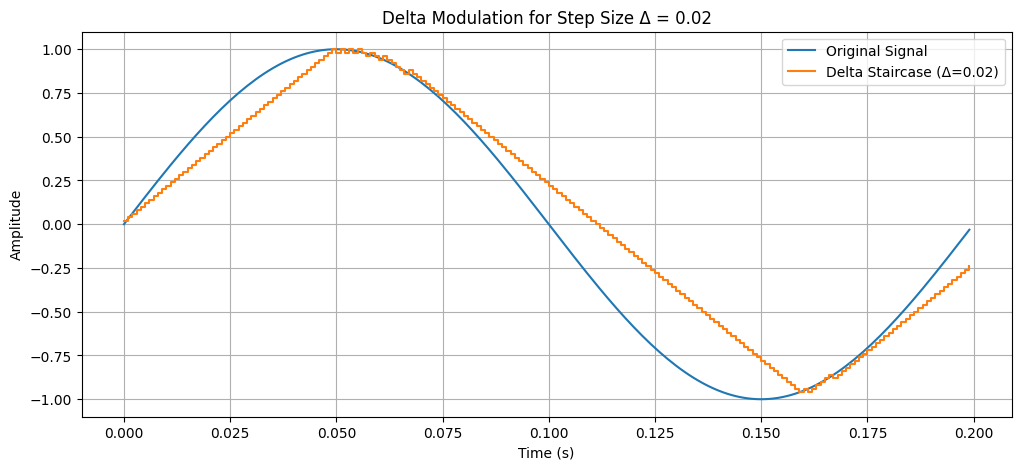

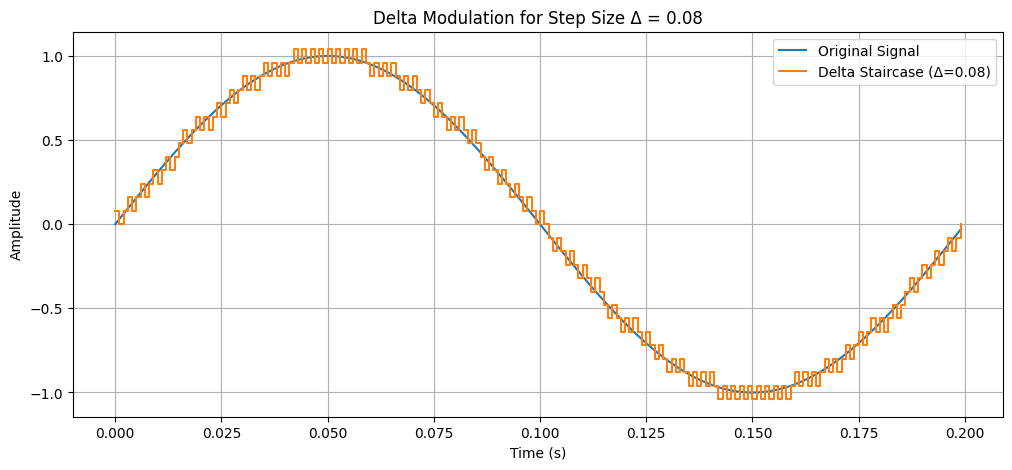

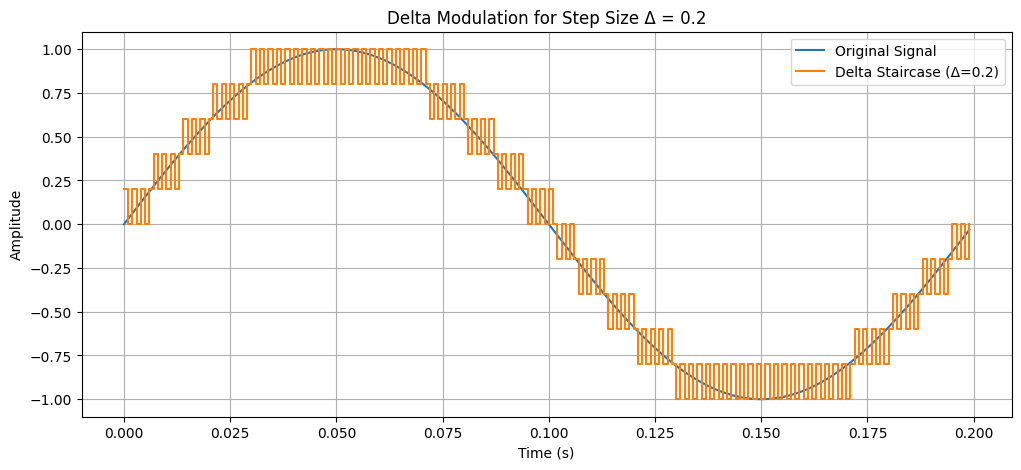

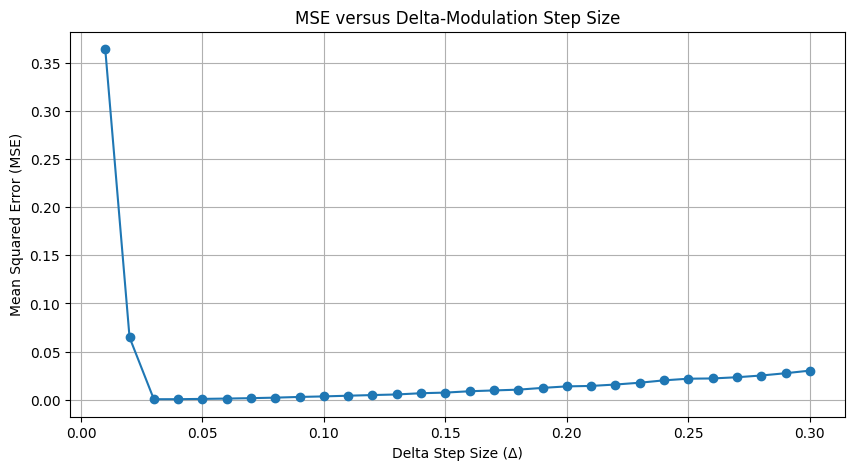

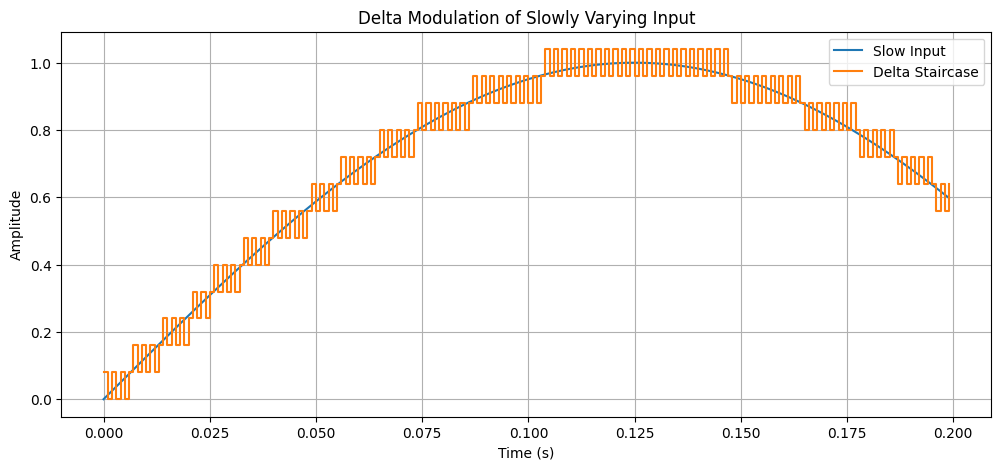

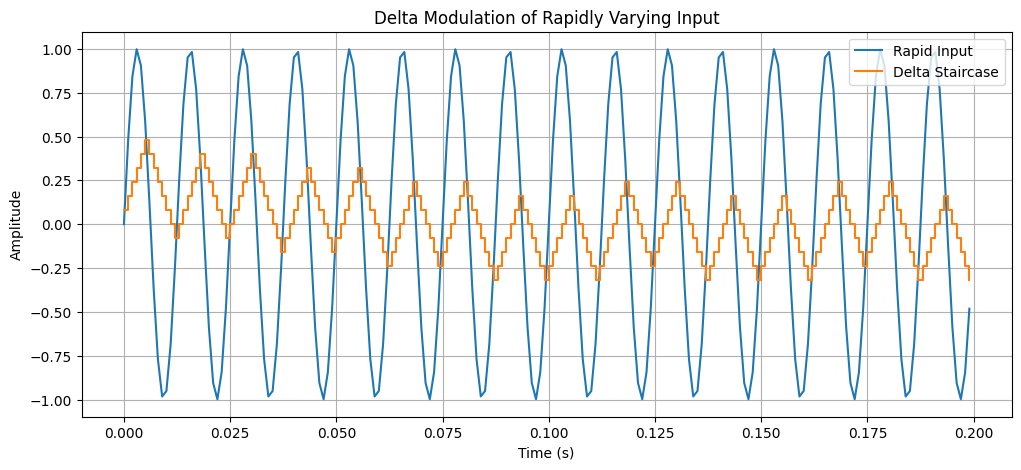


EXPERIMENT SUMMARY
DPCM MSE = 0.0007703270090782388
Delta = 0.020, MSE = 0.064725
Delta = 0.080, MSE = 0.002154
Delta = 0.200, MSE = 0.013847

Expected observations:
1. DPCM reduces redundancy by transmitting prediction error.
2. Small Delta produces granular noise.
3. Large input frequency can cause slope overload.
4. Increasing Delta reduces slope overload but may increase granular noise.
5. Every Delta-modulator staircase transition is exactly +Delta or -Delta.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 5: DPCM AND DELTA MODULATION
# ============================================================

# ---------------- USER INPUT ----------------
A = 1.0                 # Amplitude of input signal
f = 5                   # Input frequency in Hz
fs = 1000               # Sampling frequency in Hz
duration = 1.0          # Duration in seconds

# DPCM quantizer parameters
dpcm_step = 0.10        # DPCM quantization step

# Delta modulation step sizes
delta_steps = [0.02, 0.08, 0.20]

# ------------------------------------------------------------
# GENERATE INPUT SIGNAL
# ------------------------------------------------------------

t = np.arange(0, duration, 1/fs)
x = A * np.sin(2 * np.pi * f * t)

print("Number of samples:", len(x))
print("Sampling frequency:", fs, "Hz")
print("Input frequency:", f, "Hz")


# ============================================================
# PART 1: FIRST-ORDER DPCM
# ============================================================

def dpcm_encode(x, step):
    """
    First-order DPCM encoder.

    Prediction:
        x_pred[n] = reconstructed sample x_rec[n-1]

    Prediction error:
        e[n] = x[n] - x_pred[n]

    Quantization:
        e_q[n] = quantized prediction error

    Reconstruction:
        x_rec[n] = x_pred[n] + e_q[n]
    """

    N = len(x)

    # Arrays
    prediction = np.zeros(N)
    error = np.zeros(N)
    quantized_error = np.zeros(N)
    reconstruction = np.zeros(N)

    # First sample
    prediction[0] = 0
    error[0] = x[0] - prediction[0]

    # Uniform quantization
    quantized_error[0] = step * np.round(error[0] / step)

    reconstruction[0] = (
        prediction[0] + quantized_error[0]
    )

    # Remaining samples
    for n in range(1, N):

        # ---------------- PREDICTION ----------------
        prediction[n] = reconstruction[n-1]

        # ---------------- PREDICTION ERROR ----------------
        error[n] = x[n] - prediction[n]

        # ---------------- QUANTIZATION ----------------
        quantized_error[n] = (
            step * np.round(error[n] / step)
        )

        # ---------------- RECONSTRUCTION ----------------
        reconstruction[n] = (
            prediction[n] + quantized_error[n]
        )

    return prediction, error, quantized_error, reconstruction


# Run DPCM
prediction, dpcm_error, q_error, dpcm_reconstructed = \
    dpcm_encode(x, dpcm_step)

# DPCM MSE
dpcm_mse = np.mean(
    (x - dpcm_reconstructed) ** 2
)

print("\n========== DPCM RESULTS ==========")
print("DPCM Quantization Step =", dpcm_step)
print("DPCM MSE =", dpcm_mse)


# ============================================================
# DPCM VISUALIZATION
# ============================================================

samples_to_plot = 200

plt.figure(figsize=(12, 5))
plt.plot(
    t[:samples_to_plot],
    x[:samples_to_plot],
    label="Original Signal"
)
plt.plot(
    t[:samples_to_plot],
    prediction[:samples_to_plot],
    '--',
    label="Predicted Signal"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("DPCM: Original and Predicted Samples")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(
    t[:samples_to_plot],
    dpcm_error[:samples_to_plot],
    label="Prediction Error"
)
plt.plot(
    t[:samples_to_plot],
    q_error[:samples_to_plot],
    '--',
    label="Quantized Error"
)
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("DPCM Prediction Error and Quantized Error")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(
    t[:samples_to_plot],
    x[:samples_to_plot],
    label="Original"
)
plt.plot(
    t[:samples_to_plot],
    dpcm_reconstructed[:samples_to_plot],
    '--',
    label="DPCM Reconstructed"
)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("DPCM Reconstruction")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART 2: DELTA MODULATION
# ============================================================

def delta_modulation(x, delta):
    """
    Delta Modulation.

    Prediction = previous reconstructed value

    If input > previous reconstruction:
        output changes by +delta

    If input < previous reconstruction:
        output changes by -delta
    """

    N = len(x)

    staircase = np.zeros(N)
    dm_output = np.zeros(N)

    # Initial value
    staircase[0] = 0

    # First decision
    if x[0] >= staircase[0]:
        dm_output[0] = 1
        staircase[0] = staircase[0] + delta
    else:
        dm_output[0] = -1
        staircase[0] = staircase[0] - delta

    # Remaining samples
    for n in range(1, N):

        if x[n] >= staircase[n-1]:

            # Positive step
            dm_output[n] = 1
            staircase[n] = staircase[n-1] + delta

        else:

            # Negative step
            dm_output[n] = -1
            staircase[n] = staircase[n-1] - delta

    return dm_output, staircase


# ============================================================
# TEST THREE DIFFERENT STEP SIZES
# ============================================================

dm_results = {}

for delta in delta_steps:

    bits, staircase = delta_modulation(x, delta)

    mse = np.mean(
        (x - staircase) ** 2
    )

    dm_results[delta] = {
        "bits": bits,
        "staircase": staircase,
        "mse": mse
    }

    print("\n===================================")
    print("Delta =", delta)
    print("MSE   =", mse)


# ============================================================
# MANDATORY VALIDATION
# Every staircase step must be exactly +Δ or -Δ
# ============================================================

print("\n========== MANDATORY VALIDATION ==========")

for delta in delta_steps:

    staircase = dm_results[delta]["staircase"]

    changes = np.diff(staircase)

    # Ignore zero-length issue and floating point tolerance
    valid = np.all(
        np.isclose(
            np.abs(changes),
            delta,
            atol=1e-10
        )
    )

    print(
        f"Delta = {delta:.3f} : "
        f"Every output step is exactly +Delta or -Delta -> {valid}"
    )


# ============================================================
# DELTA STAIRCASE PLOTS
# ============================================================

for delta in delta_steps:

    staircase = dm_results[delta]["staircase"]

    plt.figure(figsize=(12, 5))

    plt.plot(
        t[:samples_to_plot],
        x[:samples_to_plot],
        label="Original Signal"
    )

    plt.step(
        t[:samples_to_plot],
        staircase[:samples_to_plot],
        where="post",
        label=f"Delta Staircase (Δ={delta})"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(
        f"Delta Modulation for Step Size Δ = {delta}"
    )
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# PART 3: MSE VS STEP SIZE
# ============================================================

mse_values = []

# Use a range of step sizes
step_range = np.linspace(0.01, 0.30, 30)

for delta in step_range:

    _, staircase = delta_modulation(x, delta)

    mse = np.mean(
        (x - staircase) ** 2
    )

    mse_values.append(mse)


plt.figure(figsize=(10, 5))

plt.plot(
    step_range,
    mse_values,
    marker='o'
)

plt.xlabel("Delta Step Size (Δ)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE versus Delta-Modulation Step Size")
plt.grid(True)
plt.show()


# ============================================================
# PART 4: SLOWLY VARYING INPUT
# ============================================================

f_slow = 2

x_slow = A * np.sin(
    2 * np.pi * f_slow * t
)

delta_slow = 0.08

_, staircase_slow = delta_modulation(
    x_slow,
    delta_slow
)

plt.figure(figsize=(12, 5))

plt.plot(
    t[:samples_to_plot],
    x_slow[:samples_to_plot],
    label="Slow Input"
)

plt.step(
    t[:samples_to_plot],
    staircase_slow[:samples_to_plot],
    where="post",
    label="Delta Staircase"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(
    "Delta Modulation of Slowly Varying Input"
)
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART 5: RAPIDLY VARYING INPUT
# ============================================================

f_fast = 80

x_fast = A * np.sin(
    2 * np.pi * f_fast * t
)

delta_fast = 0.08

_, staircase_fast = delta_modulation(
    x_fast,
    delta_fast
)

plt.figure(figsize=(12, 5))

plt.plot(
    t[:samples_to_plot],
    x_fast[:samples_to_plot],
    label="Rapid Input"
)

plt.step(
    t[:samples_to_plot],
    staircase_fast[:samples_to_plot],
    where="post",
    label="Delta Staircase"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(
    "Delta Modulation of Rapidly Varying Input"
)
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n========================================")
print("EXPERIMENT SUMMARY")
print("========================================")

print("DPCM MSE =", dpcm_mse)

for delta in delta_steps:

    print(
        f"Delta = {delta:.3f}, "
        f"MSE = {dm_results[delta]['mse']:.6f}"
    )

print("\nExpected observations:")
print("1. DPCM reduces redundancy by transmitting prediction error.")
print("2. Small Delta produces granular noise.")
print("3. Large input frequency can cause slope overload.")
print("4. Increasing Delta reduces slope overload but may increase granular noise.")
print("5. Every Delta-modulator staircase transition is exactly +Delta or -Delta.")